# arXiv Agent and Coding-Agent Research Pulse

This notebook tracks query-based research topics on arXiv. It is designed for fast-moving themes where category alone is too broad.

Good first topics:

- AI agents;
- coding agents;
- tool use;
- retrieval-augmented generation;
- mechanistic interpretability;
- AI for science.

Data source: arXiv API.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_publication_phrasing

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Define query pulses

The queries below are deliberately explicit. Adjust them when the arXiv API parser or field syntax requires a stricter expression.


In [2]:
topic_queries = {
    "ai_agent": 'all:"AI agent" OR all:"autonomous agent"',
    "coding_agent": 'all:"coding agent" OR all:"code agent" OR all:"program repair"',
    "tool_use": 'all:"tool use" OR all:"function calling"',
    "rag": 'all:"retrieval augmented generation" OR all:"RAG"',
    "mechanistic_interpretability": 'all:"mechanistic interpretability"',
    "ai_for_science": 'all:"AI for science" OR all:"scientific discovery"',
}
pd.DataFrame([{"topic": k, "query": v} for k, v in topic_queries.items()])


,topic,query
0,ai_agent,"all:""AI agent"" OR all:""autonomous agent"""
1,coding_agent,"all:""coding agent"" OR all:""code agent"" OR all:..."
2,tool_use,"all:""tool use"" OR all:""function calling"""
3,rag,"all:""retrieval augmented generation"" OR all:""RAG"""
4,mechanistic_interpretability,"all:""mechanistic interpretability"""
5,ai_for_science,"all:""AI for science"" OR all:""scientific discov..."


## 2. Fetch monthly topic counts


In [3]:
START_MONTH = "2025-01-01"
END_MONTH = "2026-05-01"
SLEEP_SECONDS = 3.0

cache_path = CACHE_DIR / f"arxiv_agent_topic_counts_{START_MONTH}_{END_MONTH}.csv"
if cache_path.exists():
    counts = pd.read_csv(cache_path, parse_dates=["month"])
else:
    counts = build_arxiv_monthly_counts(topic_queries, start_month=START_MONTH, end_month=END_MONTH, sleep_seconds=SLEEP_SECONDS)
    counts.to_csv(cache_path, index=False)
counts.head(12)


,month,series,query,count,source,access_date,data_quality
0,2025-01-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",65,arXiv API,2026-05-22,public_api_snapshot
1,2025-02-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",112,arXiv API,2026-05-22,public_api_snapshot
2,2025-03-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",91,arXiv API,2026-05-22,public_api_snapshot
3,2025-04-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",115,arXiv API,2026-05-22,public_api_snapshot
4,2025-05-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",173,arXiv API,2026-05-22,public_api_snapshot
5,2025-06-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",150,arXiv API,2026-05-22,public_api_snapshot
6,2025-07-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",131,arXiv API,2026-05-22,public_api_snapshot
7,2025-08-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",163,arXiv API,2026-05-22,public_api_snapshot
8,2025-09-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",158,arXiv API,2026-05-22,public_api_snapshot
9,2025-10-01,ai_agent,"all:""AI agent"" OR all:""autonomous agent""",206,arXiv API,2026-05-22,public_api_snapshot


## 3. Source audit


In [4]:
audit = source_audit_table(counts, value_col="count", entity_col="series", time_col="month")
audit


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,ai_agent,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,65.0,365.0
1,ai_for_science,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,21.0,63.0
2,coding_agent,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,8.0,118.0
3,mechanistic_interpretability,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,9.0,62.0
4,rag,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,154.0,336.0
5,tool_use,2025-01-01 00:00:00,2026-05-01 00:00:00,17,0.0,44.0,182.0


## 4. Decompose topic counts


In [5]:
components = decompose_table(
    counts,
    entity_col="series",
    time_col="month",
    value_col="count",
    method="MA_BASELINE",
    period=12,
    trend_window=5,
    transform="log1p",
)
summary = component_summary(components, entity_col="series", time_col="month")
summary


,series,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method
0,ai_agent,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.418475,0.059586,-0.477001,0.503611,2.513110,MA_BASELINE
1,ai_for_science,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.489031,0.034805,-1.013129,0.387375,14.858083,MA_BASELINE
2,coding_agent,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.792028,0.109713,0.697921,0.414089,6.951002,MA_BASELINE
3,mechanistic_interpretability,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.343744,0.047719,0.444266,0.318825,3.834405,MA_BASELINE
4,rag,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.389279,0.013511,-6.572506,0.536696,6.078962,MA_BASELINE
5,tool_use,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.035190,0.064324,-0.197874,0.467042,12.071310,MA_BASELINE


## 5. Editorial ranking

A topic with both positive trend slope and high residual shock deserves a timely post. A topic with trend but low residual is better for an evergreen explainer.


In [6]:
priority = editorial_priority(summary, entity_col="series")
priority


,series,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
2,coding_agent,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.792028,0.109713,0.697921,0.414089,6.951002,MA_BASELINE,1.000000,1.000000,0.666667,0.850000
5,tool_use,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.035190,0.064324,-0.197874,0.467042,12.071310,MA_BASELINE,0.833333,0.666667,0.833333,0.800000
1,ai_for_science,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.489031,0.034805,-1.013129,0.387375,14.858083,MA_BASELINE,0.333333,0.333333,1.000000,0.633333
3,mechanistic_interpretability,17,2025-01-01 00:00:00,2026-05-01 00:00:00,2.343744,0.047719,0.444266,0.318825,3.834405,MA_BASELINE,0.500000,0.833333,0.333333,0.491667
0,ai_agent,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.418475,0.059586,-0.477001,0.503611,2.513110,MA_BASELINE,0.666667,0.500000,0.166667,0.408333
4,rag,17,2025-01-01 00:00:00,2026-05-01 00:00:00,3.389279,0.013511,-6.572506,0.536696,6.078962,MA_BASELINE,0.166667,0.166667,0.500000,0.316667


## Visualization: AI-agent topic trend shock scatter

The scatter compares trend slope, shock magnitude, and cycle strength in the editorial priority table.

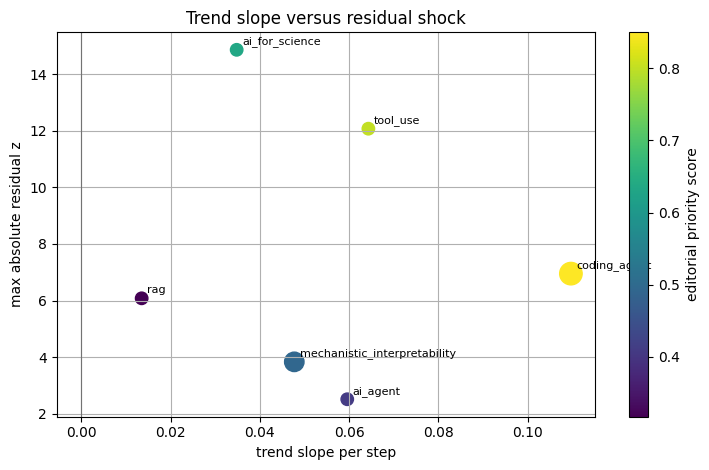

In [7]:
scatter_frame = priority.dropna(subset=["trend_slope_per_step", "max_abs_residual_z"]).copy()
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sizes = 80 + scatter_frame["cycle_strength_proxy"].fillna(0).clip(lower=0) * 260
sc = ax.scatter(
    scatter_frame["trend_slope_per_step"],
    scatter_frame["max_abs_residual_z"],
    s=sizes,
    c=scatter_frame["editorial_priority_score"],
    cmap="viridis",
)
for _, row in scatter_frame.head(8).iterrows():
    ax.annotate(str(row["series"]), (row["trend_slope_per_step"], row["max_abs_residual_z"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(0, color="0.45", linewidth=0.8)
ax.set_xlabel("trend slope per step")
ax.set_ylabel("max absolute residual z")
ax.set_title("Trend slope versus residual shock")
fig.colorbar(sc, ax=ax, label="editorial priority score")
plt.tight_layout()
plt.show()


## Visualization: AI-agent topic component panels

Observed and trend lines plus residual bars turn the component table into an inspectable trend narrative.

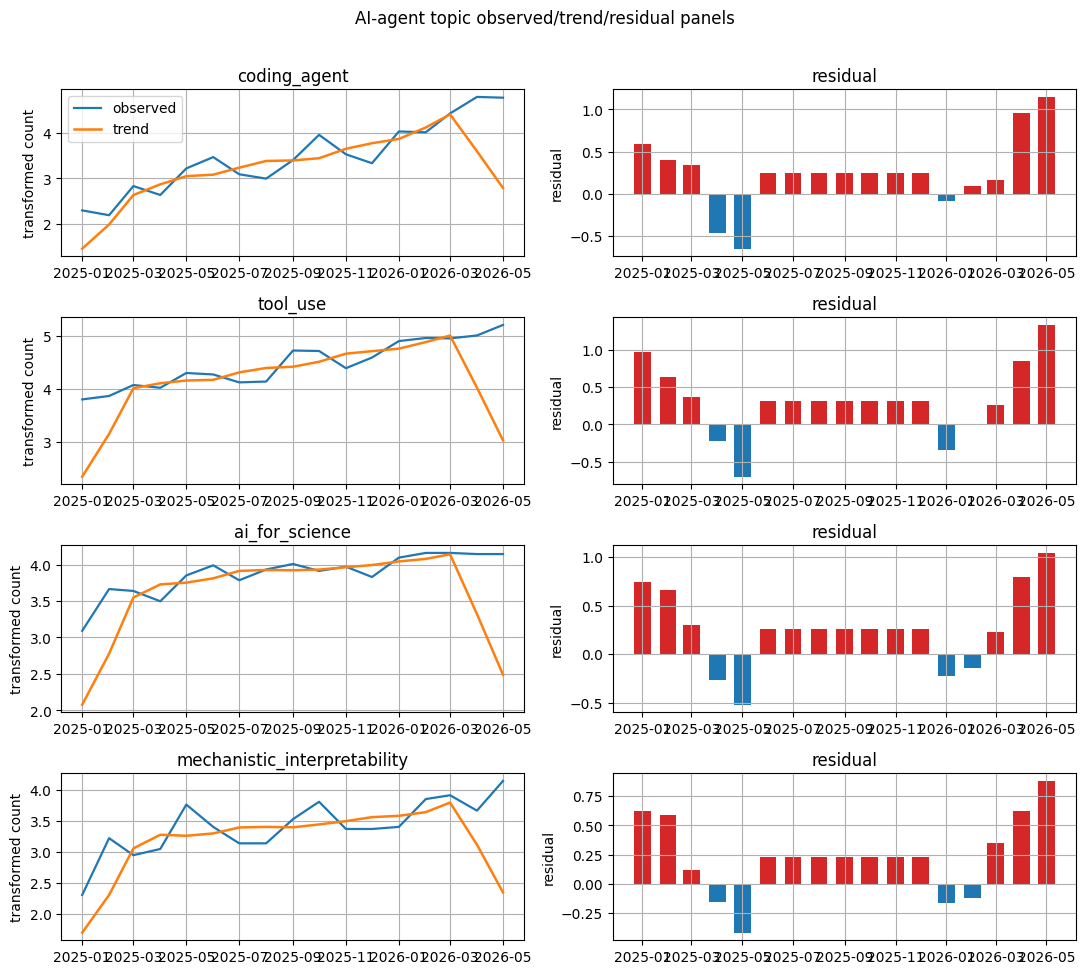

In [8]:
top_entities = priority["series"].head(4).tolist()
fig, axes = plt.subplots(len(top_entities), 2, figsize=(11, max(3.0, 2.4 * len(top_entities))), squeeze=False)
for row, entity in enumerate(top_entities):
    panel = components.loc[components["series"].eq(entity)].sort_values("month").copy()
    panel["month"] = pd.to_datetime(panel["month"])
    axes[row, 0].plot(panel["month"], panel["observed"], label="observed", linewidth=1.6)
    axes[row, 0].plot(panel["month"], panel["trend"], label="trend", linewidth=1.8)
    axes[row, 0].set_title(str(entity))
    axes[row, 1].bar(panel["month"], panel["residual"], color=np.where(panel["residual"] >= 0, "tab:red", "tab:blue"), width=20)
    axes[row, 1].set_title("residual")
    axes[row, 0].set_ylabel("transformed count")
    axes[row, 1].set_ylabel("residual")
axes[0, 0].legend(loc="best")
plt.suptitle("AI-agent topic observed/trend/residual panels", y=1.01)
plt.tight_layout()
plt.show()


## 6. Event-like months


In [9]:
events = residual_event_table(components, entity_col="series", time_col="month", top_n=20)
events


,month,series,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2026-05-01,ai_for_science,4.143135,2.489031,0.614325,1.039779,14.858083,14.858083,MA_BASELINE
1,2025-05-01,ai_for_science,3.850148,3.751483,0.614325,-0.515660,-14.858083,14.858083,MA_BASELINE
2,2026-05-01,tool_use,5.209486,3.035190,0.841468,1.332828,12.071310,12.071310,MA_BASELINE
3,2025-05-01,tool_use,4.304065,4.162151,0.841468,-0.699554,-12.071310,12.071310,MA_BASELINE
4,2025-04-01,ai_for_science,3.496508,3.727357,0.033679,-0.264529,-10.060305,10.060305,MA_BASELINE
5,2026-04-01,ai_for_science,4.143135,3.320807,0.033679,0.788648,10.060305,10.060305,MA_BASELINE
6,2026-01-01,ai_for_science,4.094345,4.042209,0.270311,-0.218175,-9.174720,9.174720,MA_BASELINE
7,2025-01-01,ai_for_science,3.091042,2.078438,0.270311,0.742294,9.174720,9.174720,MA_BASELINE
8,2025-01-01,tool_use,3.806662,2.351080,0.482440,0.973142,7.798611,7.798611,MA_BASELINE
9,2026-01-01,tool_use,4.905275,4.762703,0.482440,-0.339868,-7.798611,7.798611,MA_BASELINE


## Visualization: AI-agent topic residual heatmap

The heatmap shows where residual shocks cluster across entities and time.

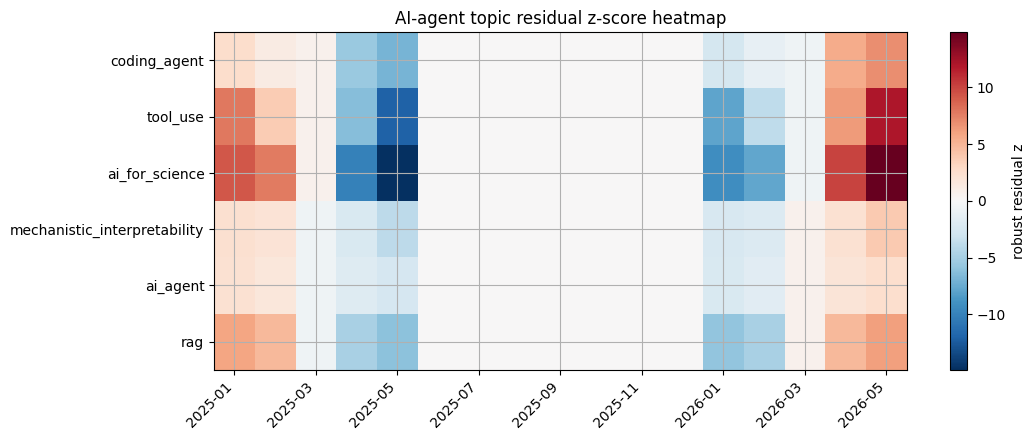

In [10]:
residual_grid = components.copy()
residual_grid["residual_z"] = residual_grid.groupby("series")["residual"].transform(lambda s: (s - s.median()) / (1.4826 * (s - s.median()).abs().median() + 1e-12))
heat = residual_grid.pivot_table(index="series", columns="month", values="residual_z", aggfunc="mean")
heat = heat.reindex(priority["series"].tolist()).dropna(how="all")
values = heat.to_numpy(dtype=float)
absmax = float(np.nanmax(np.abs(values))) if np.isfinite(values).any() else 1.0
fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(values, aspect="auto", cmap="RdBu_r", vmin=-absmax, vmax=absmax)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
tick_step = max(1, len(heat.columns) // 8)
xticks = list(range(0, len(heat.columns), tick_step))
ax.set_xticks(xticks)
ax.set_xticklabels([pd.to_datetime(heat.columns[i]).strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("AI-agent topic residual z-score heatmap")
fig.colorbar(im, ax=ax, label="robust residual z")
plt.tight_layout()
plt.show()


## 7. Article outline template


In [11]:
outline = pd.DataFrame([
    {"section": "Question", "content": "Which agent-related research topic is accelerating?"},
    {"section": "Source", "content": "arXiv API counts by query and submitted month."},
    {"section": "De-Time table", "content": "trend slope, cycle strength, residual shock rank."},
    {"section": "Interpretation scope", "content": "arXiv counts measure preprint volume; quality and adoption require separate evidence."},
])
outline


,section,content
0,Question,Which agent-related research topic is accelera...
1,Source,arXiv API counts by query and submitted month.
2,De-Time table,"trend slope, cycle strength, residual shock rank."
3,Interpretation scope,arXiv counts measure preprint volume; quality ...


In [12]:
save_table(audit, "02_arxiv_agent_topic_audit")
save_table(priority, "02_arxiv_agent_topic_priority")
save_table(events, "02_arxiv_agent_topic_residual_events")
save_table(outline, "02_arxiv_agent_article_outline")


saved: examples/hot_trends/outputs/02_arxiv_agent_topic_audit.csv
saved: examples/hot_trends/outputs/02_arxiv_agent_topic_priority.csv
saved: examples/hot_trends/outputs/02_arxiv_agent_topic_residual_events.csv
saved: examples/hot_trends/outputs/02_arxiv_agent_article_outline.csv
